
# Decision Trees & Random Forests

## What You’ll Learn in This Notebook

In this notebook, we will explore **two powerful and widely used machine learning models**:

### 1. Decision Trees 🌳
- A **Decision Tree** is like a flowchart of yes/no questions that helps make predictions.  
- Each step in the tree asks a **simple question about the data** (e.g., "Is Age > 50?", "Is Petal Length ≤ 2.5 cm?").  
- Depending on the answer, the data moves down a different branch until it reaches a final prediction (called a **leaf node**).  
- **Why they’re useful:**  
  - Easy to understand and interpret (like following rules).  
  - Can handle both numbers and categories.  
  - But: If the tree is too deep, it can memorize the data (**overfitting**) instead of learning general rules.  

---

### 2. Random Forests 🌲🌲🌲
- A **Random Forest** is a collection of many Decision Trees.  
- Each tree sees a slightly different version of the data (by sampling rows and columns).  
- All trees make predictions, and the **forest takes a vote** on the final answer.  
- **Why they’re powerful:**  
  - More accurate than a single Decision Tree.  
  - Less likely to overfit because averaging many trees smooths out noise.  
  - Work well on many real-world problems.  

---

### What We’ll Do
- **Start small**: use the classic **Iris flower dataset** to see how trees split data.  
- **Visualize a tree** to understand how it makes decisions.  
- **Compare shallow vs. deep trees** to see underfitting vs. overfitting.  
- **Build a Random Forest** to see how combining models improves results.  
- **Practice with exercises** so you can apply what you’ve learned.

---

### Why This Matters
Understanding Decision Trees and Random Forests gives you:
- A strong foundation for **interpretable machine learning**.  
- The ability to handle both small and large datasets.  
- A stepping stone to more advanced models like **Gradient Boosting** and **Neural Networks**.

---


## What You’ll Learn

By the end of this notebook, you will be able to:

- **Know when to use tree-based models**  
  - Linear models like Logistic Regression work best when data can be separated by a straight line (or plane).  
  - Decision Trees shine when data has **non-linear patterns** or when rules like "If Age > 50 and Admission Type = Emergency" are important.

- **Understand how Decision Trees split data**  
  - A tree keeps asking **yes/no questions** about the features (e.g., “Is petal length ≤ 2.45 cm?”).  
  - Each split aims to make the resulting groups “purer” (containing mostly one class).  
  - If allowed to grow too deep, trees can **overfit** (memorize training data instead of learning general rules).

- **See how Random Forests improve Decision Trees**  
  - Instead of relying on just one tree, a Random Forest builds **many trees** on different random subsets of the data.  
  - The final prediction is made by **majority vote**.  
  - This reduces overfitting and usually makes predictions more reliable.

- **Evaluate models beyond simple accuracy**  
  - Accuracy tells us the percentage of correct predictions, but it doesn’t reveal the full story.  
  - We’ll also use:
    - **Precision**: of the predicted positives, how many were actually correct?  
    - **Recall**: of the actual positives, how many did we catch?  
    - **F1-score**: a balance of precision and recall.  
    - **Confusion Matrix**: a table showing which classes the model is getting right or confusing.

- **Interpret feature importances**  
  - Random Forests tell us which features (e.g., Age, Billing Amount, Medical Condition) matter the most in making predictions.  
  - This helps us understand the **drivers of decisions** in the model.




## Setup
Run this cell to import the libraries we'll use.


In [1]:

import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris, load_digits, make_moons
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report, confusion_matrix

# Utility: a simple function to plot a confusion matrix without specifying colors.
def plot_confusion_matrix(cm, class_names, title="Confusion Matrix"):
    fig, ax = plt.subplots(figsize=(5, 4))
    im = ax.imshow(cm)  # do not specify colors
    ax.set_title(title)
    ax.set_xlabel("Predicted label")
    ax.set_ylabel("True label")
    ax.set_xticks(range(len(class_names)))
    ax.set_yticks(range(len(class_names)))
    ax.set_xticklabels(class_names, rotation=45, ha="right")
    ax.set_yticklabels(class_names)

    # Show counts in each cell
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, cm[i, j], ha="center", va="center")
    fig.colorbar(im, ax=ax)
    plt.tight_layout()
    plt.show()

print("Imports ready.")    


Imports ready.


## 1) Quick Recap — Linear vs. Nonlinear Boundaries

- **Logistic Regression** is a *linear model*.  
  Imagine drawing a **straight line** (in 2D) or a **flat plane** (in 3D) that separates the classes.  
  - Works well if the data is already nicely separated in a straight line.  
  - Example: separating tall vs. short people by height.  

- But **not all problems are linear.**  
  Sometimes data looks like spirals, circles, or other shapes where a straight line won’t work.  

- **Decision Trees** solve this by making **step-by-step rules**.  
  Instead of one big line, they create **rectangular regions** (like boxes) by asking questions such as:  
  - “Is `petal_length ≤ 2.5 cm`?”  
  - “Is `age > 50`?”  

Each question splits the space into smaller, simpler groups.  
The result is a set of **boxes or regions** where each region corresponds to a prediction.  

---

📊 **Example with Iris flowers**  
- First, the tree might ask: *“Is petal length ≤ 2.45 cm?”*  
  - If yes → almost always **Setosa**.  
  - If no → ask another question, like *“Is petal width ≤ 1.75 cm?”*  

This way, the tree builds a sequence of rules that divide the flower dataset into meaningful groups.  



## 2) Decision Trees on Iris
We'll start with a single Decision Tree and visualize it.


Decision Tree (max_depth=3) — Accuracy: 0.895

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        12
  versicolor       0.80      0.92      0.86        13
   virginica       0.91      0.77      0.83        13

    accuracy                           0.89        38
   macro avg       0.90      0.90      0.90        38
weighted avg       0.90      0.89      0.89        38



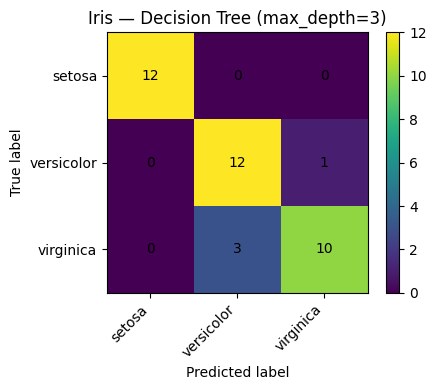

In [5]:

# Load Iris dataset
iris = load_iris()
X, y = iris.data, iris.target
feature_names = iris.feature_names
class_names = iris.target_names

# Train / Test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

# Train a shallow Decision Tree (good for visualization)
tree_clf = DecisionTreeClassifier(max_depth=3, random_state=42)
tree_clf.fit(X_train, y_train)

# Evaluate
y_pred = tree_clf.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print(f"Decision Tree (max_depth=3) — Accuracy: {acc:.3f}\n")

print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=class_names))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
plot_confusion_matrix(cm, class_names=class_names, title="Iris — Decision Tree (max_depth=3)")



### Visualizing the Tree
The plot below shows the *questions* the tree asks at each split.


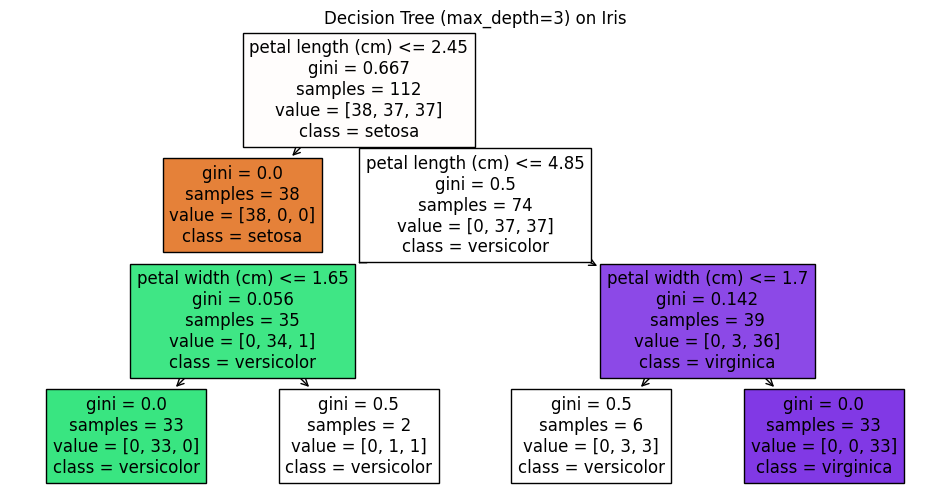

In [6]:

plt.figure(figsize=(12, 6))
plot_tree(tree_clf, feature_names=feature_names, class_names=class_names, filled=True)
plt.title("Decision Tree (max_depth=3) on Iris")
plt.show()


## Understanding the Decision Tree on Iris (max_depth = 3)

This tree shows how the model classifies flowers into three species:  
**Setosa**, **Versicolor**, and **Virginica**, based on sepal/petal measurements.

- **Root Node (top box)**:  
  The first question is: **Is petal length ≤ 2.45 cm?**  
  - If **Yes** → the flower is predicted as **Setosa**.  
  - If **No** → the model asks another question.

- **Gini index**:  
  Measures how "pure" the node is.  
  - `gini = 0` means all samples in that node belong to one class (perfectly pure).  
  - Higher gini values mean more mixing of classes.

- **Samples**:  
  The number of training examples that reached that node.  
  Example: `samples = 112` at the top node means all 112 training examples were considered.

- **Value**:  
  Counts of each class at that node, in the order `[Setosa, Versicolor, Virginica]`.  
  Example: `[38, 37, 37]` means 38 Setosa, 37 Versicolor, 37 Virginica are present.

- **Class**:  
  The majority class chosen as the prediction for that node.

### Key Splits
1. **Petal length ≤ 2.45 cm** → almost perfectly separates **Setosa** (left branch).  
2. For non-Setosa, the next split is **petal length ≤ 4.85 cm**, dividing Versicolor and Virginica.  
3. Further splits use **petal width** thresholds to refine classification.

### Takeaway
- The model learns **simple rules** like "short petals = Setosa".  
- With a depth limit of 3, the tree is easier to read but may not capture all details.  
- This visualization shows *how interpretable decision trees are* compared to other models.


## 3) Overfitting vs. Underfitting (with a Nonlinear Dataset)

When we train machine learning models, we need to balance **simplicity** and **complexity**:

- **Underfitting** (model too simple)  
  - The model does not capture the true patterns in the data.  
  - Example: using a very shallow Decision Tree (like only 1–2 questions).  
  - It makes broad, oversimplified rules and misses important details.  

- **Overfitting** (model too complex)  
  - The model memorizes the training data instead of learning general rules.  
  - Example: a very deep Decision Tree that keeps splitting until each leaf has very few points.  
  - It predicts training data perfectly but fails on new (unseen) data.  

---

📊 **Our Plan**  
We’ll demonstrate this with a **nonlinear dataset** shaped like two interleaving half-moons:

- Train a **shallow Decision Tree** (`max_depth=2`).  
  - It will make simple cuts but may not separate the moons well → **underfitting**.  

- Train a **deep Decision Tree** (no depth limit).  
  - It will carve the moons into many small regions, fitting noise too closely → **overfitting**.  

---

✨ **Key Lesson:**  
- Shallow trees are too simple → they generalize poorly.  
- Deep trees are too specific → they memorize instead of generalizing.  
- The best model usually lies **somewhere in between**.


In [7]:

# Create a nonlinear (moon-shaped) dataset
X_moon, y_moon = make_moons(n_samples=1000, noise=0.25, random_state=42)
Xm_train, Xm_test, ym_train, ym_test = train_test_split(X_moon, y_moon, test_size=0.25, random_state=42, stratify=y_moon)

# Shallow tree
shallow = DecisionTreeClassifier(max_depth=2, random_state=42)
shallow.fit(Xm_train, ym_train)
y_shallow = shallow.predict(Xm_test)
acc_shallow = accuracy_score(ym_test, y_shallow)

# Deep tree
deep = DecisionTreeClassifier(max_depth=None, random_state=42)  # fully grown
deep.fit(Xm_train, ym_train)
y_deep = deep.predict(Xm_test)
acc_deep = accuracy_score(ym_test, y_deep)

print(f"Shallow Tree (max_depth=2) — Test Accuracy: {acc_shallow:.3f}")
print(f"Deep Tree (no max depth) — Test Accuracy: {acc_deep:.3f}\n")

print("Observation: The deep tree will often fit training data very closely but can generalize worse if noise is present.")


Shallow Tree (max_depth=2) — Test Accuracy: 0.932
Deep Tree (no max depth) — Test Accuracy: 0.948

Observation: The deep tree will often fit training data very closely but can generalize worse if noise is present.



### Visual intuition
We'll plot simple decision regions for the shallow and deep trees. Each chart is separate to keep it clean.


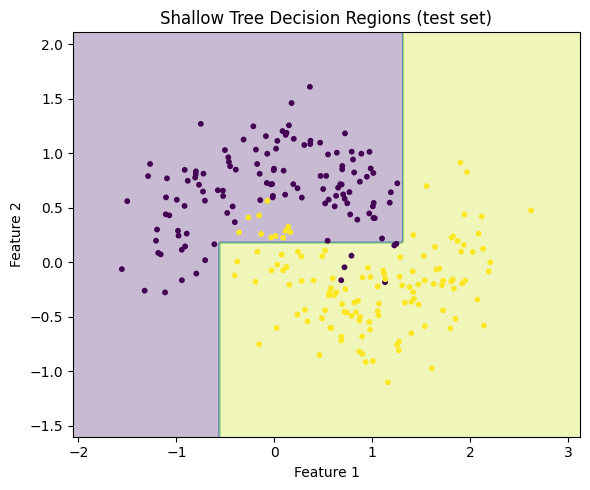

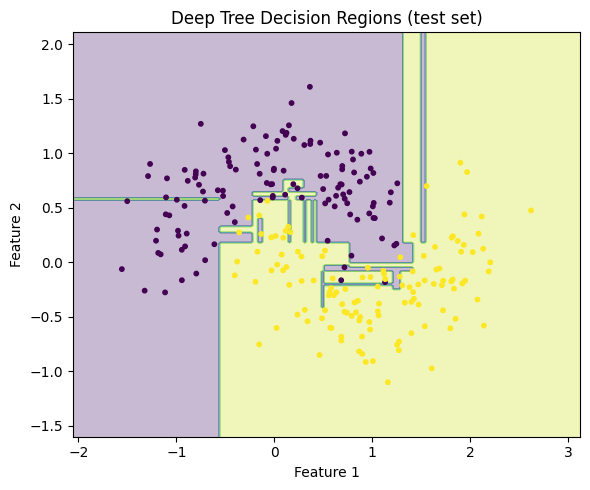

In [8]:

def plot_decision_boundary(model, X, y, title):
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200), np.linspace(y_min, y_max, 200))
    grid = np.c_[xx.ravel(), yy.ravel()]
    Z = model.predict(grid).reshape(xx.shape)

    plt.figure(figsize=(6, 5))
    plt.contourf(xx, yy, Z, alpha=0.3)  # do not specify colors
    plt.scatter(X[:, 0], X[:, 1], c=y, s=10)  # do not specify colors
    plt.title(title)
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.tight_layout()
    plt.show()

plot_decision_boundary(shallow, Xm_test, ym_test, "Shallow Tree Decision Regions (test set)")
plot_decision_boundary(deep, Xm_test, ym_test, "Deep Tree Decision Regions (test set)")



## 4) Random Forests: Many Trees, One Vote
A Random Forest trains many trees on slightly different views of the data and lets them **vote**.  
This usually improves accuracy and reduces overfitting.


Random Forest — Accuracy: 0.921

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        12
  versicolor       0.86      0.92      0.89        13
   virginica       0.92      0.85      0.88        13

    accuracy                           0.92        38
   macro avg       0.92      0.92      0.92        38
weighted avg       0.92      0.92      0.92        38



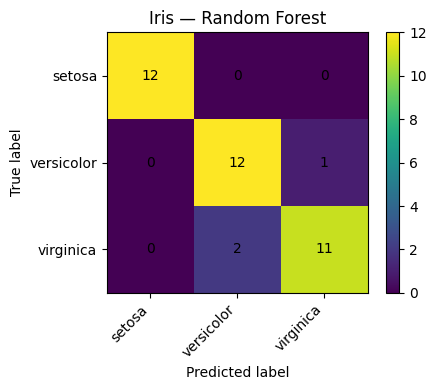

In [9]:

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_rf = rf.predict(X_test)

acc_rf = accuracy_score(y_test, y_rf)
print(f"Random Forest — Accuracy: {acc_rf:.3f}\n")
print("Classification Report:")
print(classification_report(y_test, y_rf, target_names=class_names))

cm_rf = confusion_matrix(y_test, y_rf)
plot_confusion_matrix(cm_rf, class_names=class_names, title="Iris — Random Forest")



### Which features matter?
Random Forests provide a measure of **feature importance**. Higher values mean the feature contributed more to the splits across the forest.


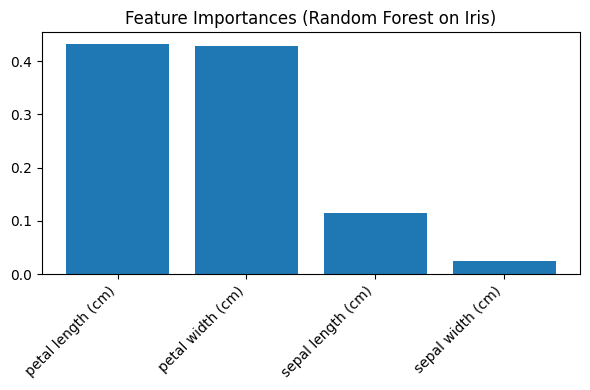

In [10]:

importances = rf.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(6,4))
plt.bar(range(len(importances)), importances[indices])
plt.xticks(range(len(importances)), np.array(feature_names)[indices], rotation=45, ha="right")
plt.title("Feature Importances (Random Forest on Iris)")
plt.tight_layout()
plt.show()



## 5) Mini-Challenge: Handwritten Digits
Let's practice on the built-in **Digits** dataset (1797 images of size 8×8).  
We'll train a Random Forest and inspect the confusion matrix.


Digits — Random Forest Accuracy: 0.964

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.96      0.97        45
           1       0.94      0.96      0.95        46
           2       1.00      0.98      0.99        44
           3       0.94      1.00      0.97        46
           4       0.96      1.00      0.98        45
           5       0.98      0.96      0.97        46
           6       1.00      0.98      0.99        45
           7       0.96      1.00      0.98        45
           8       0.95      0.88      0.92        43
           9       0.95      0.93      0.94        45

    accuracy                           0.96       450
   macro avg       0.96      0.96      0.96       450
weighted avg       0.96      0.96      0.96       450



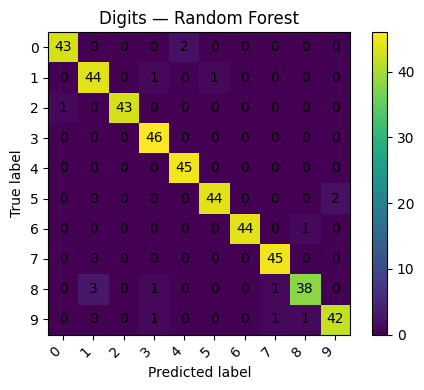

In [11]:

digits = load_digits()
Xd, yd = digits.data, digits.target
Xd_train, Xd_test, yd_train, yd_test = train_test_split(Xd, yd, test_size=0.25, random_state=42, stratify=yd)

rf_digits = RandomForestClassifier(n_estimators=150, random_state=42)
rf_digits.fit(Xd_train, yd_train)
yd_pred = rf_digits.predict(Xd_test)

acc_digits = accuracy_score(yd_test, yd_pred)
print(f"Digits — Random Forest Accuracy: {acc_digits:.3f}\n")
print("Classification Report:")
print(classification_report(yd_test, yd_pred))

cm_digits = confusion_matrix(yd_test, yd_pred)
plot_confusion_matrix(cm_digits, class_names=[str(i) for i in range(10)], title="Digits — Random Forest")



## 6) Your Turn — Exercises
1. **Tree Depth Experiment**  
   - Change `max_depth` of the Decision Tree (try `None`, `2`, `4`, `6`) and compare test accuracy.
2. **Forest Size Experiment**  
   - Change `n_estimators` in `RandomForestClassifier` (try `10`, `50`, `200`) and compare.
3. **Add a Validation Split**  
   - When you split the data, keep a separate validation set to tune hyperparameters.
4. **Confusion Matrices**  
   - Plot confusion matrices for each experiment and note which classes are confused.
5. **Digits Challenge**  
   - Try `max_features='sqrt'` or `max_depth=10` in the Digits Random Forest. Does it help?



## 7) Key Takeaways
- **Decision Trees** split data using simple questions. They are intuitive but can **overfit** if grown too deep.
- **Random Forests** combine many trees and generally improve accuracy and robustness.
- Always look beyond accuracy: check **precision**, **recall**, **F1**, and **confusion matrices**.
- Feature importances help explain **which features the model uses** most.
- Next steps: **Gradient Boosting** (e.g., XGBoost, LightGBM) and an introduction to **Neural Networks**.
